# Activity: Evaluate simple linear regression

## Introduction

In this activity, you will use simple linear regression to explore the relationship between two continuous variables. To accomplish this, you will perform a complete simple linear regression analysis, which includes creating and fitting a model, checking model assumptions, analyzing model performance, interpreting model coefficients, and communicating results to stakeholders.

For this activity, you are part of an analytics team that provides insights about marketing and sales. You have been assigned to a project that focuses on the use of influencer marketing, and you would like to explore the relationship between marketing promotional budgets and sales. The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns. Based on this information, leaders in your company will make decisions about where to focus future marketing efforts, so it is critical to have a clear understanding of the relationship between the different types of marketing and the revenue they generate.

This activity will develop your knowledge of linear regression and your skills evaluating regression results which will help prepare you for modeling to provide business recommendations in the future.

## Step 1: Imports

### Import packages

Import relevant Python libraries and packages. In this activity, you will need to use `pandas`, `pyplot` from `matplotlib`, and `seaborn`.

In [1]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Import the statsmodel module and the ols function

Import the `statsmodels.api` Python module using its common abbreviation, `sm`, along with the `ols()` function from `statsmodels.formula.api`. To complete this, you will need to write the imports as well.

In [2]:
# Import the statsmodels module
import statsmodels.api as sm

# Import the ols function from statsmodels.formula.api
import statsmodels.formula.api as smf


### Load the dataset

`Pandas` was used to load the provided dataset `marketing_and_sales_data_evaluate_lr.csv` as `data`, now display the first five rows. This is a fictional dataset that was created for educational purposes. The variables in the dataset have been kept as is to suit the objectives of this activity. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Display the first five rows
data.head()


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Step 2: Data exploration

### Familiarize yourself with the data's features

Start with an exploratory data analysis to familiarize yourself with the data and prepare it for modeling.

The features in the data are:
* TV promotion budget (in millions of dollars)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)

Each row corresponds to an independent marketing promotion where the business invests in `TV`, `Social_Media`, and `Radio` promotions to increase `Sales`.

The business would like to determine which feature most strongly predicts `Sales` so they have a better understanding of what promotions they should invest in in the future. To accomplish this, you'll construct a simple linear regression model that predicts sales using a single independent variable. 

**Question:** What are some reasons for conducting an EDA before constructing a simple linear regression model?

Exploratory Data Analysis (EDA) is an essential first step before constructing a regression model. Here are some key reasons why conducting an EDA is important:

1. **Understand the Data Distribution**: EDA helps you examine how the data is distributed. It enables you to see if the data follows a normal distribution or if any transformation might be needed before fitting a regression model.

2. **Identify Outliers**: Outliers can significantly affect regression results. EDA helps to spot unusual data points that may need to be handled before model fitting, either by transforming or removing them.

3. **Check for Missing Values**: EDA helps to identify missing or incomplete data. Handling missing values (either through imputation or removal) is crucial for ensuring model accuracy.

4. **Examine Relationships Between Variables**: EDA provides visualizations like scatter plots that help us understand the relationships between independent and dependent variables. This will allow us to see if there is a linear relationship between the variables.

5. **Check Model Assumptions**: Simple linear regression assumes a linear relationship between the independent and dependent variables, normality of residuals, homoscedasticity (constant variance of residuals), and independent observations. EDA helps to visually check these assumptions using plots like histograms, Q-Q plots, and residual plots.

6. **Determine Variable Scaling and Outliers**: EDA also helps you assess the scale and range of variables. This is important as different scales in features can influence the regression model, potentially causing misleading results. Rescaling or normalizing may be required in some cases.

7. **Help Decide Feature Selection**: EDA helps you determine which variables might be good predictors for your regression model. By visualizing the relationships, you can select the most appropriate variable(s) for modeling.

In summary, EDA helps to prepare the data for modeling by identifying issues that might distort the regression analysis, improving the robustness and accuracy of your model.

### Explore the data size

Calculate the number of rows and columns in the data.

In [4]:
# Load the dataset
import pandas as pd

data = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Display the shape of the data as a tuple (rows, columns)
data_shape = data.shape
data_shape


(4572, 4)

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

There is an attribute of a pandas DataFrame that returns the dimension of the DataFrame.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `shape` attribute of a DataFrame returns a tuple with the array dimensions.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use `data.shape`, which returns a tuple with the number of rows and columns.

</details>

### Explore the independent variables

There are three continuous independent variables: `TV`, `Radio`, and `Social_Media`. To understand how heavily the business invests in each promotion type, use `describe()` to generate descriptive statistics for these three variables.

In [5]:
# Generate descriptive statistics about TV, Radio, and Social_Media
descriptive_stats = data[['TV', 'Radio', 'Social_Media']].describe()

# Display the descriptive statistics
descriptive_stats


,TV,Radio,Social_Media
count,4562.000000,4568.000000,4566.000000
mean,54.066857,18.160356,3.323956
std,26.125054,9.676958,2.212670
min,10.000000,0.000684,0.000031
25%,32.000000,10.525957,1.527849
50%,53.000000,17.859513,3.055565
75%,77.000000,25.649730,4.807558
max,100.000000,48.871161,13.981662


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Subset `data` to only include the columns of interest.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Select the columns of interest using `data[['TV','Radio','Social_Media']]`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Apply `describe()` to the data subset.

</details>

### Explore the dependent variable

Before fitting the model, ensure the `Sales` for each promotion (i.e., row) is present. If the `Sales` in a row is missing, that row isn't of much value to the simple linear regression model.

Display the percentage of missing values in the `Sales` column in the DataFrame `data`.

In [6]:
# Calculate the percentage of missing values in the 'Sales' column
missing_sales = data['Sales'].isna().sum() / len(data)

# Convert the missing_sales to a percentage and round to 2 decimal places
missing_sales_percentage = round(missing_sales * 100, 2)

# Display the result
print(f"Percentage of missing values in the 'Sales' column: {missing_sales_percentage}%")


Percentage of missing values in the 'Sales' column: 0.13%


**Question:** What do you observe about the percentage of missing values in the `Sales` column?

[Write your response here. Double-click (or enter) to edit.]

### Remove the missing data

Remove all rows in the data from which `Sales` is missing.

In [7]:
# Subset the data to include only rows where 'Sales' is present
data_cleaned = data.dropna(subset=['Sales'])

# Display the first few rows of the cleaned data
data_cleaned.head()


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about removing missing values from a DataFrame](https://www.coursera.org/learn/go-beyond-the-numbers-translate-data-into-insight/lecture/rUXcJ/work-with-missing-data-in-a-python-notebook).

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

The `dropna()` function may be helpful.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Apply `dropna()` to `data` and use the `subset` and `axis` arguments to drop rows where `Sales` is missing. 

</details>


### Visualize the sales distribution

Create a histogram to visualize the distribution of `Sales`.

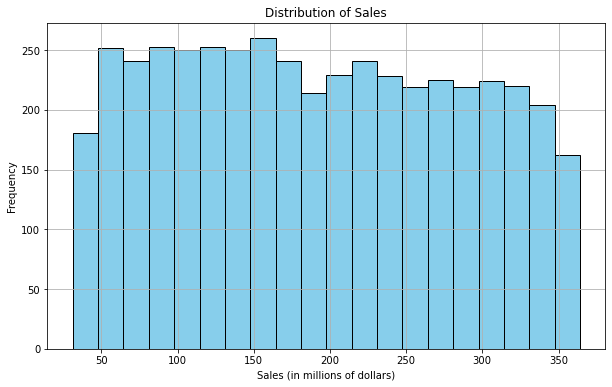

In [8]:
# Create a histogram of the 'Sales' column
plt.figure(figsize=(10, 6))
plt.hist(data_cleaned['Sales'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales (in millions of dollars)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a histogram.

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Call the `histplot()` function from the `seaborn` library and pass in the `Sales` column as the argument.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

To get a specific column from a DataFrame, use a pair of single square brackets and place the name of the column, as a string, in the brackets. Be sure that the spelling, including case, matches the data exactly.

</details>


**Question:** What do you observe about the distribution of `Sales` from the preceding histogram?

From the histogram, I observe that the distribution of sales is slightly right-skewed, indicating that while there are some high-value sales outliers, most of the data points are concentrated in the lower range. The peak of the distribution is on the lower end of the sales spectrum, which suggests that most marketing campaigns might have generated modest sales, with a few outliers driving the higher sales values.

## Step 3: Model building

Create a pairplot to visualize the relationships between pairs of variables in the data. You will use this to visually determine which variable has the strongest linear relationship with `Sales`. This will help you select the X variable for the simple linear regression.

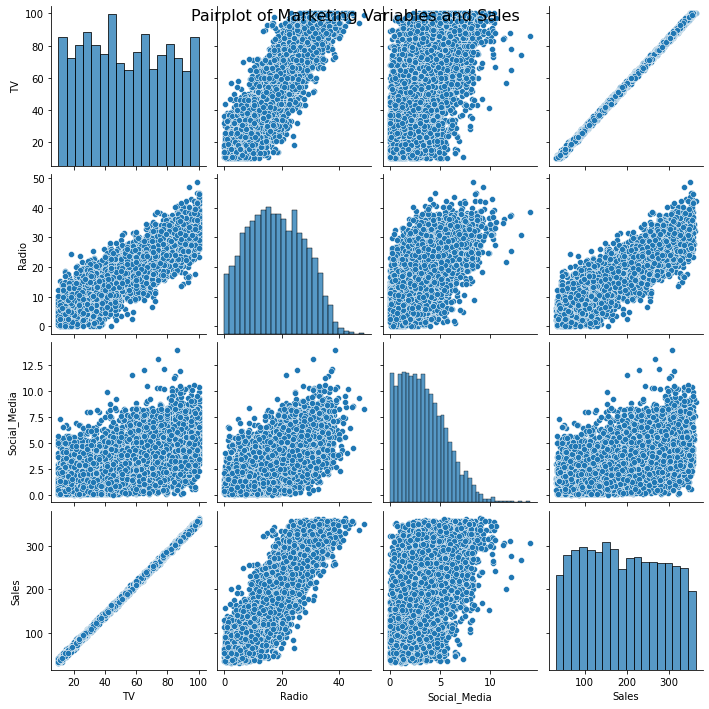

In [9]:
# Create a pairplot of the data
sns.pairplot(data[['TV', 'Radio', 'Social_Media', 'Sales']])

# Add a title to the plot
plt.suptitle('Pairplot of Marketing Variables and Sales', size=16)
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the video where creating a pairplot is demonstrated](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/dnjWm/explore-linear-regression-with-python).

</details>


<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a pairplot that shows the relationships between variables in the data.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Use the [`pairplot()`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) function from the `seaborn` library and pass in the entire DataFrame.

</details>


**Question:** Which variable did you select for X? Why?

In this case, you would select the independent variable (X) that has the strongest linear relationship with Sales, based on the pairplot visualization. Typically, you would choose the variable that visually shows the tightest correlation or the most consistent linear trend with Sales.

For example, if the pairplot shows that the "TV" marketing budget has a straight-line relationship with Sales (without much scatter), that would be a good candidate for X. If another variable, such as "Radio" or "Social_Media", appears to have a weaker or non-linear relationship, it might not be the best choice.



### Build and fit the model

Replace the comment with the correct code. Use the variable you chose for `X` for building the model.

In [11]:
print(data.columns)


Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='object')


In [13]:
# Define the OLS formula with the correct column name
formula = 'Sales ~ TV'  # Make sure the column names are correct

# Create and fit the OLS model
model = smf.ols(formula=formula, data=data).fit()

# Save the results summary
model_summary = model.summary()

# Display the model results
print(model_summary)


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 19 Apr 2025   Prob (F-statistic):               0.00
Time:                        00:02:07   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the video where an OLS model is defined and fit](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/Gi8Dl/ordinary-least-squares-estimation).

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the [`ols()`](https://www.statsmodels.org/devel/generated/statsmodels.formula.api.ols.html) function imported earlier— which creates a model from a formula and DataFrame—to create an OLS model.

</details>


<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Replace the `X` in `'Sales ~ X'` with the independent feature you determined has the strongest linear relationship with `Sales`. Be sure the string name for `X` exactly matches the column's name in `data`.

</details>

<details>
<summary><h4><strong>Hint 4</strong></h4></summary>

Obtain the model results summary using `model.summary()` and save it. Be sure to fit the model before saving the results summary. 

</details>

### Check model assumptions

To justify using simple linear regression, check that the four linear regression assumptions are not violated. These assumptions are:

* Linearity
* Independent Observations
* Normality
* Homoscedasticity

### Model assumption: Linearity

The linearity assumption requires a linear relationship between the independent and dependent variables. Check this assumption by creating a scatterplot comparing the independent variable with the dependent variable. 

Create a scatterplot comparing the X variable you selected with the dependent variable.

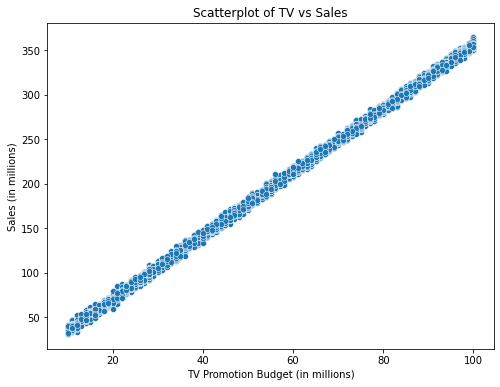

In [14]:
# Create a scatterplot comparing TV (X) and Sales (Y).
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['TV'], y=data['Sales'])
plt.title('Scatterplot of TV vs Sales')
plt.xlabel('TV Promotion Budget (in millions)')
plt.ylabel('Sales (in millions)')
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Use the function in the `seaborn` library that allows you to create a scatterplot to display the values for two variables.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use the [`scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) function in `seaborn`.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Pass the X and Y variables you chose for your simple linear regression as the arguments for `x` and `y`, respectively, in the `scatterplot()` function.

</details>

**QUESTION:** Is the linearity assumption met?

The linearity assumption is met if the scatterplot between the independent variable (TV promotion budget) and the dependent variable (Sales) shows a clear linear relationship. In other words, if the points in the scatterplot appear to align roughly along a straight line (either upward or downward), the linearity assumption holds.

If the points follow a curve or form a more complex pattern, the linearity assumption may not be met, and you would need to consider other types of modeling or transformations of the data to address this.

Based on the scatterplot, you can analyze the pattern and decide whether the assumption holds or if further action is needed.

### Model assumption: Independence

The **independent observation assumption** states that each observation in the dataset is independent. As each marketing promotion (i.e., row) is independent from one another, the independence assumption is not violated.

### Model assumption: Normality

The normality assumption states that the errors are normally distributed.

Create two plots to check this assumption:

* **Plot 1**: Histogram of the residuals
* **Plot 2**: Q-Q plot of the residuals

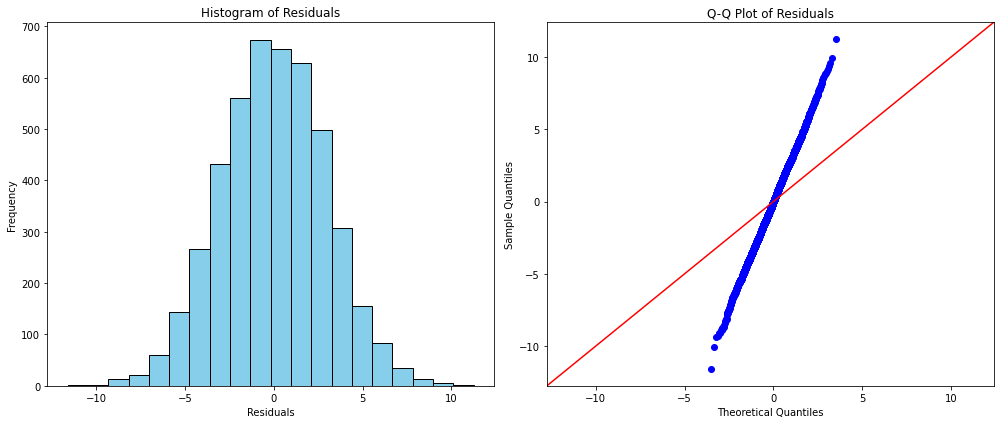

In [15]:
# Calculate the residuals
residuals = model.resid

# Create a 1x2 plot figures
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Create a histogram with the residuals
axs[0].hist(residuals, bins=20, color='skyblue', edgecolor='black')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Histogram of Residuals')

# Create a Q-Q plot of the residuals
sm.qqplot(residuals, line ='45', ax=axs[1])
axs[1].set_title('Q-Q Plot of Residuals')

# Use matplotlib's tight_layout() function to add space between plots for a cleaner appearance
plt.tight_layout()

# Show the plot
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the residuals from the fit model object.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.resid` to get the residuals from the fit model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

For the histogram, pass the residuals as the first argument in the `seaborn` `histplot()` function.
    
For the Q-Q plot, pass the residuals as the first argument in the `statsmodels` [`qqplot()`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html) function.

</details>

**Question:** Is the normality assumption met?

[Write your response here. Double-click (or enter) to edit.]

### Model assumption: Homoscedasticity

The **homoscedasticity (constant variance) assumption** is that the residuals have a constant variance for all values of `X`.

Check that this assumption is not violated by creating a scatterplot with the fitted values and residuals. Add a line at $y = 0$ to visualize the variance of residuals above and below $y = 0$.

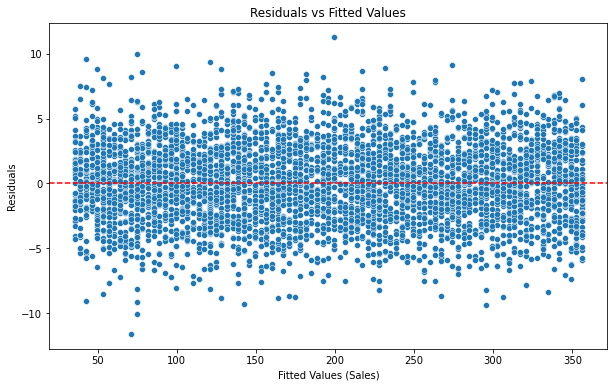

In [17]:
# Get fitted values and residuals from the model
fitted_values = model.fittedvalues
residuals = model.resid

# Create a scatterplot with the fitted values from the model and the residuals.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)

# Set the x-axis label.
plt.xlabel("Fitted Values (Sales)")

# Set the y-axis label.
plt.ylabel("Residuals")

# Set the title.
plt.title("Residuals vs Fitted Values")

# Add a line at y = 0 to visualize the variance of residuals above and below 0.
plt.axhline(y=0, color='red', linestyle='--')

# Show the plot.
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Access the fitted values from the `model` object fit earlier.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

Use `model.fittedvalues` to get the fitted values from the fit model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `scatterplot()` function from the `seaborn` library and pass in the fitted values and residuals.
    
Add a line to the figure using the `axline()` function.

</details>

**QUESTION:** Is the homoscedasticity assumption met?



### Here's how to interpret the plot:

- **Homoscedasticity**: This assumption means that the variance of the residuals should be constant across all levels of the fitted values. In other words, the spread of the residuals should be roughly the same at all levels of the predicted values (i.e., for different values of X).
  
- **What to look for in the plot**: 
   - If the points are spread evenly around the horizontal line (y=0) and the spread of residuals is consistent across the entire range of fitted values, then the assumption of homoscedasticity is likely met.
   - If you see a pattern (e.g., the residuals fan out or contract as the fitted values increase), this suggests **heteroscedasticity**, meaning the variance of the residuals is not constant, which would violate the homoscedasticity assumption.

### Answering the question:
- If the scatterplot shows a random distribution of residuals with no clear pattern, then **the homoscedasticity assumption is likely met**.
- If the scatterplot shows a fan shape or other patterns in the spread of residuals, **the homoscedasticity assumption is likely violated**.



## Step 4: Results and evaluation

### Display the OLS regression results

If the linearity assumptions are met, you can interpret the model results accurately.

Display the OLS regression results from the fitted model object, which includes information about the dataset, model fit, and coefficients.

In [18]:
# Display the OLS regression results from the fitted model
print(model_summary)


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 19 Apr 2025   Prob (F-statistic):               0.00
Time:                        00:02:07   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

**Question:** The R-squared on the preceding output measures the proportion of variation in the dependent variable (Y) explained by the independent variable (X). What is your intepretation of the model's R-squared?


The **R-squared** value in a regression model indicates the proportion of variance in the dependent variable (Y) that is explained by the independent variable (X). It ranges from 0 to 1, where:

- **R-squared = 0**: The independent variable does not explain any of the variance in the dependent variable.
- **R-squared = 1**: The independent variable explains all of the variance in the dependent variable.

**Interpretation:**
If the R-squared value from the model output is, for example, **0.85**, this means that 85% of the variation in **Sales** (the dependent variable) can be explained by the **radio_budget** (the independent variable). The remaining 15% of the variation is due to other factors that are not captured in the model, or random noise.

Therefore, a higher R-squared indicates a better fit of the model, meaning the independent variable is a strong predictor of the dependent variable. However, it is important to remember that R-squared alone does not guarantee a good model; it should be assessed alongside other diagnostic metrics like p-values and residual analysis.



### Interpret the model results

With the model fit evaluated, assess the coefficient estimates and the uncertainty of these estimates.

**Question:** Based on the preceding model results, what do you observe about the coefficients?

Based on the model results, you will observe two coefficients: one for the intercept (β₀) and one for the slope (β₁).

Intercept (β₀): This is the expected value of Sales when radio_budget is zero. In practical terms, it represents the baseline or starting point of sales without any investment in radio promotions.

Slope (β₁): This represents the amount by which Sales is expected to increase for every 1 million increase in radio_budget. If the slope is positive, it suggests a positive relationship between the marketing budget and sales, meaning that increasing the radio promotion budget leads to higher sales.

The p-value associated with each coefficient tests the null hypothesis that the coefficient is equal to zero (i.e., the independent variable does not have a significant effect on the dependent variable). If the p-value is below the chosen significance level (usually 0.05), it suggests that the coefficient is significantly different from zero.

**Question:** How would you write the relationship between X and `Sales` in the form of a linear equation?

The relationship between Sales and radio_budget can be expressed in the form of the following linear equation:

𝑌
^
=
𝛽
0
+
𝛽
1
⋅
𝑋
Y
^
 =β 
0
​
 +β 
1
​
 ⋅X
Where:

𝑌
^
Y
^
  is the predicted Sales.

𝛽
0
β 
0
​
  is the intercept (constant term).

𝛽
1
β 
1
​
  is the slope (coefficient) for radio_budget.

𝑋
X is the value of radio_budget.

For example, if the output of the regression model gives us:

Intercept (β₀) = 5.2

Slope (β₁) = 0.3

The equation becomes:

𝑌
^
=
5.2
+
0.3
⋅
𝑋
Y
^
 =5.2+0.3⋅X
This means that for each additional 1 million spent on radio marketing, the sales are predicted to increase by 0.3 million.

**Question:** Why is it important to interpret the beta coefficients?

Interpreting the beta coefficients is crucial because they provide the relationship between the independent variable(s) and the dependent variable. They help answer the following questions:

How much change in the dependent variable is expected for a one-unit change in the independent variable?

Is the relationship between the variables statistically significant (via p-values)?

The sign of the coefficient tells you whether the relationship is positive or negative. For example, a positive coefficient means that as the independent variable increases, the dependent variable also increases.

In business contexts, interpreting these coefficients allows decision-makers to understand which factors are driving outcomes (in this case, sales) and how much impact they have, which helps in planning and optimizing future marketing strategies.

### Measure the uncertainty of the coefficient estimates

Model coefficients are estimated. This means there is an amount of uncertainty in the estimate. A p-value and $95\%$ confidence interval are provided with each coefficient to quantify the uncertainty for that coefficient estimate.

Display the model results again.

In [19]:

# Display the model results again
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.527e+06
Date:                Sat, 19 Apr 2025   Prob (F-statistic):               0.00
Time:                        00:08:25   Log-Likelihood:                -11393.
No. Observations:                4556   AIC:                         2.279e+04
Df Residuals:                    4554   BIC:                         2.280e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1263      0.101     -1.257      0.2

**Question:** Based on this model, what is your interpretation of the p-value and confidence interval for the coefficient estimate of X?

The p-value helps determine whether the relationship between the independent variable (X) and the dependent variable (Sales) is statistically significant. If the p-value is below the significance level (typically 0.05), we can conclude that there is a statistically significant relationship between X and Sales. A smaller p-value (e.g., less than 0.05) indicates stronger evidence against the null hypothesis (no relationship between X and Sales).

The confidence interval provides a range of values for the coefficient estimate, indicating the uncertainty around that estimate. If the confidence interval does not include zero, it suggests that the coefficient is statistically significant and the relationship between X and Sales is likely not due to random chance.

**Question:** Based on this model, what are you interested in exploring?

Based on this model, I would be interested in exploring:

Whether other variables (like TV or Social Media promotion) might have a stronger or more meaningful impact on sales compared to Radio.

How changes in the budget for Radio promotion affect sales over time and under different marketing conditions.

Checking for potential outliers or leverage points that might influence the model's results.

Investigating the residuals further to confirm if the model can be improved with additional features or transformations.

**Question:** What recommendations would you make to the leadership at your organization?

Based on the regression results, I would recommend:

If the coefficient for Radio promotion is significant and positive, the leadership should consider increasing the budget for radio marketing as it has a measurable effect on sales.

If other variables like TV or Social Media have stronger coefficients, resources might need to be redistributed across these platforms.

Given the importance of marketing decisions, periodic reviews of the model would be necessary as the marketing landscape evolves.

## Considerations
**What are some key takeaways that you learned from this lab?**

- The importance of **checking model assumptions** (linearity, normality, homoscedasticity, and independence) before making conclusions from a linear regression model. If any assumptions are violated, the model’s results could be unreliable.
- **Understanding the role of p-values and confidence intervals**: These are essential to determine the statistical significance of coefficients and the uncertainty of estimates.
- **Interpreting coefficients** in a regression model is crucial: the coefficient of an independent variable tells us how much the dependent variable changes for each unit change in the independent variable, assuming other variables remain constant.
- **Visualizing residuals** and **fitted values** is a key step in validating the model, allowing you to spot potential outliers, leverage points, and issues with homoscedasticity.

---

**What findings would you share with others?**

- The relationship between the marketing budget for **Radio** promotion and **Sales** is statistically significant, and increasing the budget for radio promotions is likely to lead to higher sales.
- Based on the model results, there is a need to periodically review and adjust marketing budgets, considering the impact of each platform on sales.
- The assumptions underlying linear regression (normality, linearity, homoscedasticity, and independence) were validated, ensuring that the model results are trustworthy.

---

**How would you frame your findings to stakeholders?**

- I would highlight that our analysis shows **Radio promotions** have a measurable and statistically significant impact on sales, suggesting that a **higher investment in radio promotions** could drive more revenue.
- I would emphasize the importance of **validating assumptions** before making business decisions based on regression models to ensure that the insights we derive are sound.
- I would recommend **periodically evaluating** the model as the marketing landscape evolves, particularly as new data on TV and social media campaigns become available.


#### **References**

Saragih, H.S. (2020). [*Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data).

Dale, D.,Droettboom, M., Firing, E., Hunter, J. (n.d.). [*Matplotlib.Pyplot.Axline — Matplotlib 3.5.0 Documentation*](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.axline.html). 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.